# Задача 3

In [ ]:
!pip install mlforecast neuralforecast window-ops

In [ ]:
# imports
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from window_ops.rolling import rolling_mean, rolling_std

# ML & DL
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, LSTM

# Anomaly Detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats

In [ ]:
# Constants
DIR_TASK1="task1_outputs"
DIR_TASK3="task3_outputs"
RANDOM_STATE=42
CSV="time_series_60min_singleindex.csv"
LAGS=[1, 24, 48, 168]
MLM=['LGBMRegressor', 'RandomForestRegressor', 'GradientBoostingRegressor']
DLM=['NBEATS', 'NHITS', 'LSTM']
ROLLS=[24, 168]
EQUALS=50
COL_DS="ds"
COL_Y="y"
COL_UID="unique_id"

In [ ]:
# Отключаем предупреждения
warnings.filterwarnings('ignore')

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Создаем директорию для сохранения результатов
Path(DIR_TASK3).mkdir(parents=True, exist_ok=True)

## 3.1 ПОДГОТОВКА ДАННЫХ

In [ ]:
df_train = pd.read_csv(f"{DIR_TASK1}/train.csv")
df_test = pd.read_csv(f"{DIR_TASK1}/test_clean.csv")

In [ ]:
train = df_train.copy()
test = df_test.copy()

In [ ]:
train[COL_UID] = "FR_Load"
train[COL_DS] = pd.to_datetime(train[COL_DS])
train = train.sort_values([COL_UID, COL_DS]).reset_index(drop=True)

test = test.drop(columns="Unnamed: 0")
test[COL_UID] = "FR_Load"
test[COL_DS] = pd.to_datetime(test[COL_DS])
test = test.sort_values([COL_UID, COL_DS]).reset_index(drop=True)

print(f"Train: {len(train)} записей,\nTest: {len(test)} записей")

Train: 39896 записей,
Test: 10017 записей


In [ ]:
print("train")
print(train.dtypes)
print()
print("test")
print(test.dtypes)

train
ds               datetime64[ns, UTC]
y                            float64
hour                           int64
dayofweek                      int64
month                          int64
is_weekend                     int64
hour_sin                     float64
hour_cos                     float64
month_sin                    float64
month_cos                    float64
lag_1                        float64
lag_24                       float64
lag_48                       float64
lag_168                      float64
roll_mean_24                 float64
roll_mean_168                float64
roll_std_24                  float64
unique_id                     object
dtype: object

test
ds           datetime64[ns, UTC]
y                        float64
unique_id                 object
dtype: object


## 3.2 FEATURE ENGINEERING (MLFORECAST)

In [ ]:
# models ML

lgb = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)

rfr = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE
)

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)

In [ ]:
df_train = train[[COL_UID, COL_DS, COL_Y]].copy()
df_test = test[[COL_UID, COL_DS]].copy()

In [ ]:
print("df_train")
print(df_train.dtypes)
print()
print("df_test")
print(df_test.dtypes)

df_train
unique_id                 object
ds           datetime64[ns, UTC]
y                        float64
dtype: object

df_test
unique_id                 object
ds           datetime64[ns, UTC]
dtype: object


In [ ]:
X_df = df_test.copy()
X_df['hour'] = X_df['ds'].dt.hour
X_df['dayofweek'] = X_df['ds'].dt.dayofweek
X_df['month'] = X_df['ds'].dt.month
X_df['day'] = X_df['ds'].dt.day
X_df

,unique_id,ds,hour,dayofweek,month,day
0,FR_Load,2019-07-28 09:00:00+00:00,9,6,7,28
1,FR_Load,2019-07-28 10:00:00+00:00,10,6,7,28
2,FR_Load,2019-07-28 11:00:00+00:00,11,6,7,28
3,FR_Load,2019-07-28 12:00:00+00:00,12,6,7,28
4,FR_Load,2019-07-28 13:00:00+00:00,13,6,7,28
...,...,...,...,...,...,...
10012,FR_Load,2020-09-17 13:00:00+00:00,13,3,9,17
10013,FR_Load,2020-09-17 14:00:00+00:00,14,3,9,17
10014,FR_Load,2020-09-17 15:00:00+00:00,15,3,9,17
10015,FR_Load,2020-09-17 16:00:00+00:00,16,3,9,17


In [ ]:
# Настройка MLForecast
# Мы используем Differences(24) для удаления суточной сезонности перед обучением
mlf = MLForecast(
    models=[lgb, rfr, gbr],
    freq='H',
    lags=[1, 2, 3, 24, 48, 72, 168, 336], # LAGS, #[1, 2, 24, 48, 168], # Предыдущий час, вчера, позавчера, неделя назад
    lag_transforms={
        1: [(rolling_mean, 24)],
        24: [(rolling_mean, 7*24)],
        24: [(rolling_std, 7*24)],
        168: [(rolling_mean, 4*168)]
    },
    date_features=['hour', 'dayofweek', 'month', 'day'],
    #target_transforms=[Differences([24])] # Сезонное дифференцирование
)

print("Обучение ML моделей...")
mlf.fit(df_train)

Обучение ML моделей...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2881
[LightGBM] [Info] Number of data points in the train set: 39057, number of used features: 15
[LightGBM] [Info] Start training from score 53755.701513


MLForecast(models=[LGBMRegressor, RandomForestRegressor, GradientBoostingRegressor], freq=H, lag_features=['lag1', 'lag2', 'lag3', 'lag24', 'lag48', 'lag72', 'lag168', 'lag336', 'rolling_mean_lag1_window_size24', 'rolling_std_lag24_window_size168', 'rolling_mean_lag168_window_size672'], date_features=['hour', 'dayofweek', 'month', 'day'], num_threads=1)

In [ ]:
ml_preds = mlf.predict(len(X_df))
ml_preds.head(3)

# Слияние прогноза с тестовыми данными для оценки
test_eval = test.merge(ml_preds, on=['unique_id', 'ds'], how='left')
test_eval

,ds,y,unique_id,LGBMRegressor,RandomForestRegressor,GradientBoostingRegressor
0,2019-07-28 09:00:00+00:00,39988.0,FR_Load,40738.869152,40222.10,41355.331905
1,2019-07-28 10:00:00+00:00,41946.0,FR_Load,43071.198546,42284.33,43363.990215
2,2019-07-28 11:00:00+00:00,40636.0,FR_Load,43156.983175,43893.19,43559.736526
3,2019-07-28 12:00:00+00:00,39164.0,FR_Load,41701.530187,42047.36,42700.043234
4,2019-07-28 13:00:00+00:00,38030.0,FR_Load,40606.233366,40352.58,41952.976725
...,...,...,...,...,...,...
10012,2020-09-17 13:00:00+00:00,50845.0,FR_Load,51317.297745,50503.58,50370.489304
10013,2020-09-17 14:00:00+00:00,49681.0,FR_Load,50199.840418,49246.17,50108.334485
10014,2020-09-17 15:00:00+00:00,48863.0,FR_Load,49367.459644,48389.76,49769.890667
10015,2020-09-17 16:00:00+00:00,49055.0,FR_Load,49716.496088,49092.27,49393.760917


In [ ]:
# Расчет метрик для ML
ml_metrics = {}
for model in MLM:
    mae = np.mean(np.abs(test_eval['y'] - test_eval[model]))
    rmse = np.sqrt(np.mean((test_eval['y'] - test_eval[model])**2))
    ml_metrics[model] = {'MAE': mae, 'RMSE': rmse}

ml_metrics_df = pd.DataFrame(ml_metrics).T
ml_metrics_df.to_csv(f"{DIR_TASK3}/ml.csv")
print("\n📊 Метрики ML моделей:")
print(ml_metrics_df.round(2))


📊 Метрики ML моделей:
                               MAE      RMSE
LGBMRegressor              7322.99   9672.27
RandomForestRegressor      6164.54   8615.16
GradientBoostingRegressor  7897.77  10431.05


In [ ]:
print(df_train['ds'].max())
print(df_test['ds'].min())

print(test['y'].describe())

for m in MLM:
    print(m)
    print(ml_preds[m].describe())

2019-07-28 08:00:00+00:00
2019-07-28 09:00:00+00:00
count    10017.000000
mean     49715.395228
std      10880.730213
min      29398.000000
25%      41454.000000
50%      47721.000000
75%      57204.000000
max      82832.000000
Name: y, dtype: float64
LGBMRegressor
count    10017.000000
mean     47105.701771
std       5302.765579
min      34111.853106
25%      42597.606060
50%      48857.788339
75%      50984.236155
max      55304.372331
Name: LGBMRegressor, dtype: float64
RandomForestRegressor
count    10017.000000
mean     46766.394845
std       5615.359323
min      31654.520000
25%      42564.550000
50%      47848.360000
75%      51069.970000
max      57980.670000
Name: RandomForestRegressor, dtype: float64
GradientBoostingRegressor
count    10017.000000
mean     46316.875692
std       3787.189321
min      34366.164502
25%      43447.737673
50%      47538.951458
75%      49058.334158
max      54571.330045
Name: GradientBoostingRegressor, dtype: float64


## 3.3 DEEP LEARNING FORECASTING (NEURALFORECAST)

In [ ]:
cols_needed = ['unique_id', 'ds', 'y']
train_dl = train[cols_needed].copy()
# Для теста пока тоже оставляем только базовые колонки
test_dl = test[cols_needed].copy()

In [ ]:
input_size = 168 # Например, модель смотрит на последние 168 часов (неделя)
h = 24           # Прогнозируем на 24 часа вперед

# Берем последние input_size строк из train
history_for_test = train_dl.iloc[-input_size:].copy()

# Объединяем историю и будущий тест
# (Предполагается, что в test_dl уже есть будущие 'ds' и 'unique_id', а 'y' там может быть NaN или реальные значения для оценки)
test_dl_full = pd.concat([history_for_test, test_dl], ignore_index=True)

# Сортируем по времени, чтобы не было хаоса
test_dl_full = test_dl_full.sort_values('ds').reset_index(drop=True)

In [ ]:
# models DL

nbeats = NBEATS(
    h=336,
    input_size=336*2,
    max_steps=100,
    scaler_type='robust',
    random_seed=RANDOM_STATE,
    accelerator='gpu',
    devices=1,
)

nhits = NHITS(
    h=336,
    input_size=336*2,
    max_steps=100,
    scaler_type='robust',
    random_seed=RANDOM_STATE,
    accelerator='gpu',
    devices=1,
)

lstm = LSTM(
    h=336,
    input_size=336*2,
    max_steps=100,
    scaler_type='robust',
    random_seed=RANDOM_STATE,
    accelerator='gpu',
    devices=1,
)

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42


In [ ]:
print("Обучение DL моделей (это может занять 1-3 минуты)...")
# DL модели требуют указания горизонта (h) и размера входа (input_size)
# Для ускорения демо max_steps уменьшен. В продакшене ставьте 1000+
nf = NeuralForecast(
    models=[nbeats, nhits, lstm],
    freq='H'
)

nf.fit(df=train_dl)

Обучение DL моделей (это может занять 1-3 минуты)...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.3 M  | train
-------------------------------------------------------
4.6 M     Trainable params
678 K     Non-trainable params
5.3 M     Total params
21.134    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 199 K  | train
4 | mlp_decoder  | MLP           | 16.6 K | train
-------------------------------------------------------
215 K     Trainable params
0         Non-trainable params
215 K     Total params
0.863     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.


In [ ]:
print(f"Количество строк в train_dl: {len(train_dl)}")
print(f"Минимально необходимо для текущих настроек: {input_size + h} (т.е. {168 + 24} = 192)")

if len(train_dl) < (input_size + h):
    raise ValueError("В тренировочном наборе слишком мало данных для DL-моделей!")

Количество строк в train_dl: 39896
Минимально необходимо для текущих настроек: 192 (т.е. 192 = 192)


In [ ]:
dl_preds = nf.predict(df=test_dl_full, h=336)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Оценка DL
dl_metrics = {}
for model_name in DLM:
    mae = np.mean(np.abs(test_eval['y'] - dl_preds[model_name]))
    rmse = np.sqrt(np.mean((test_eval['y'] - dl_preds[model_name])**2))
    dl_metrics[model_name] = {'MAE': mae, 'RMSE': rmse}

dl_metrics_df = pd.DataFrame(dl_metrics).T

print("\Метрики DL моделей:")
print(dl_metrics_df.round(2))

# Сохранение метрик
dl_metrics_df.to_csv(f"{DIR_TASK3}/dl.csv")

\Метрики DL моделей:
            MAE     RMSE
NBEATS  7882.91  9502.17
NHITS   7790.50  9443.91
LSTM    7897.97  9499.19


In [ ]:
# Сохранение метрик ML & DL
pd.concat([ml_metrics_df, dl_metrics_df]).to_csv(f"{DIR_TASK3}/ml_dl_comparison.csv")

##  3.4 ВЫЯВЛЕНИЕ АНОМАЛИЙ (ANOMALY DETECTION)

In [ ]:
print("Выявление аномалий на основе остатков лучшей ML модели...")

# 1. Определяем лучшую ML модель
best_ml_model = ml_metrics_df['RMSE'].idxmin()

# 2. Генерируем признаки для тренировочных данных (вместо несуществующего predict_in_sample)
train_features = mlf.preprocess(df_train)

# 3. Выделяем только колонки с признаками (исключаем идентификаторы и целевую переменную)
feature_cols = [col for col in train_features.columns if col not in ['unique_id', 'ds', 'y']]

# 4. Делаем предсказания на тренировочных данных с помощью лучшей обученной модели
best_model = mlf.models_[best_ml_model]
in_sample_preds = best_model.predict(train_features[feature_cols])

# 5. Формируем датафрейм с предсказаниями для последующего merge
train_preds = train_features[['unique_id', 'ds']].copy()
train_preds[best_ml_model] = in_sample_preds

# 6. Объединяем с исходными данными для расчета остатков
train_eval = df_train.merge(train_preds, on=['unique_id', 'ds'], how='left')
train_eval['residuals'] = train_eval['y'] - train_eval[best_ml_model]
train_eval = train_eval.dropna() # Убираем NaN, возникшие из-за лаговых признаков

# --- Подготовка признаков для детектора ---
# Добавляем safeguard на случай, если hour и dayofweek не были созданы на этапе feature engineering
if 'hour' not in train_eval.columns:
    train_eval['hour'] = train_eval['ds'].dt.hour
if 'dayofweek' not in train_eval.columns:
    train_eval['dayofweek'] = train_eval['ds'].dt.dayofweek

X_ad = train_eval[['residuals', 'hour', 'dayofweek']].values

# Метод 1: Isolation Forest (Изолирующий лес)
iso_forest = IsolationForest(contamination=0.02, random_state=42)
train_eval['anomaly_iso'] = iso_forest.fit_predict(X_ad) # -1 аномалия, 1 норма

# Метод 2: Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
train_eval['anomaly_lof'] = lof.fit_predict(X_ad)

# Метод 3: Rolling Z-Score (Статистический метод на остатках)
window = 24 * 7 # Недельное окно
train_eval['roll_mean'] = train_eval['residuals'].rolling(window).mean()
train_eval['roll_std'] = train_eval['residuals'].rolling(window).std()
train_eval['z_score'] = np.abs((train_eval['residuals'] - train_eval['roll_mean']) / train_eval['roll_std'])
train_eval['anomaly_zscore'] = np.where(train_eval['z_score'] > 3, -1, 1) # > 3 стд = аномалия

# Итоговая метка аномалии (ансамбль: если 2 из 3 методов считают аномалией)
train_eval['anomaly_ensemble'] = np.where(
    (train_eval[['anomaly_iso', 'anomaly_lof', 'anomaly_zscore']] == -1).sum(axis=1) >= 2,
    -1, 1
)

anomalies = train_eval[train_eval['anomaly_ensemble'] == -1]
print(f"Найдено аномалий (ансамблевый метод): {len(anomalies)} ({len(anomalies)/len(train_eval)*100:.2f}%)")

Выявление аномалий на основе остатков лучшей ML модели...
Найдено аномалий (ансамблевый метод): 420 (1.08%)


## 3.5 ВИЗУАЛИЗАЦИЯ И ОТЧЕТ

Генерация отчетов и графиков...


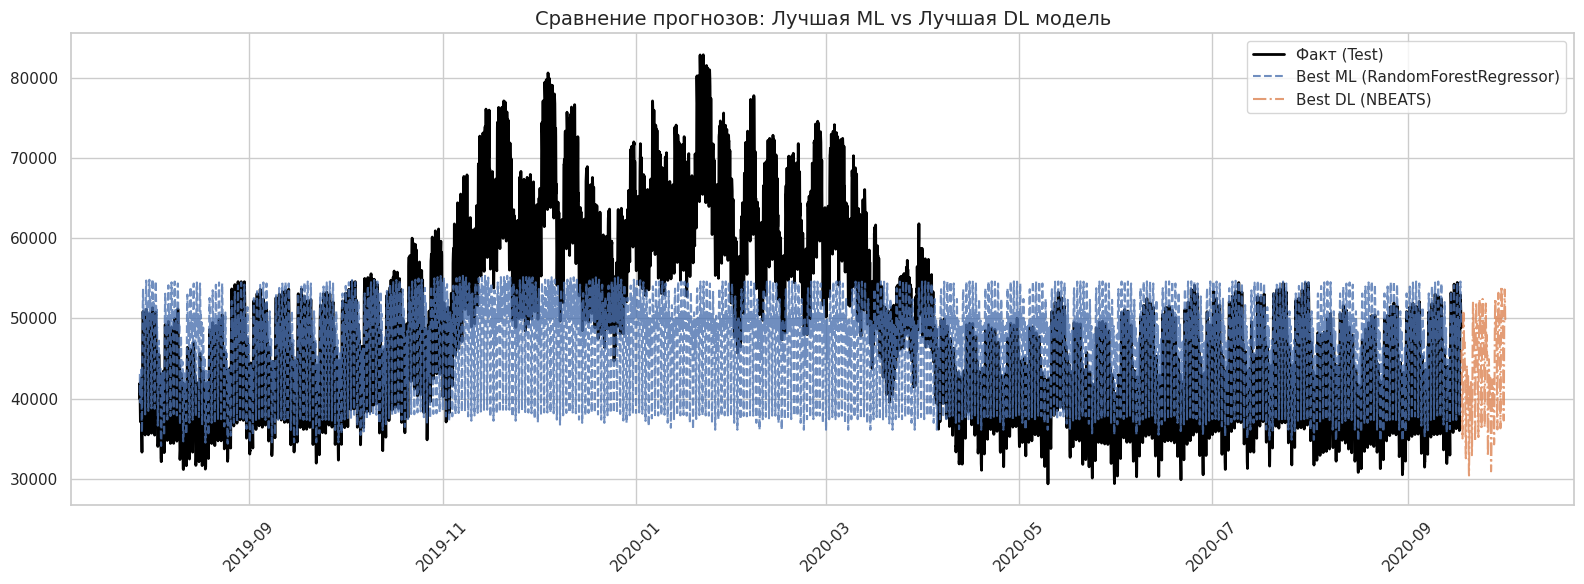

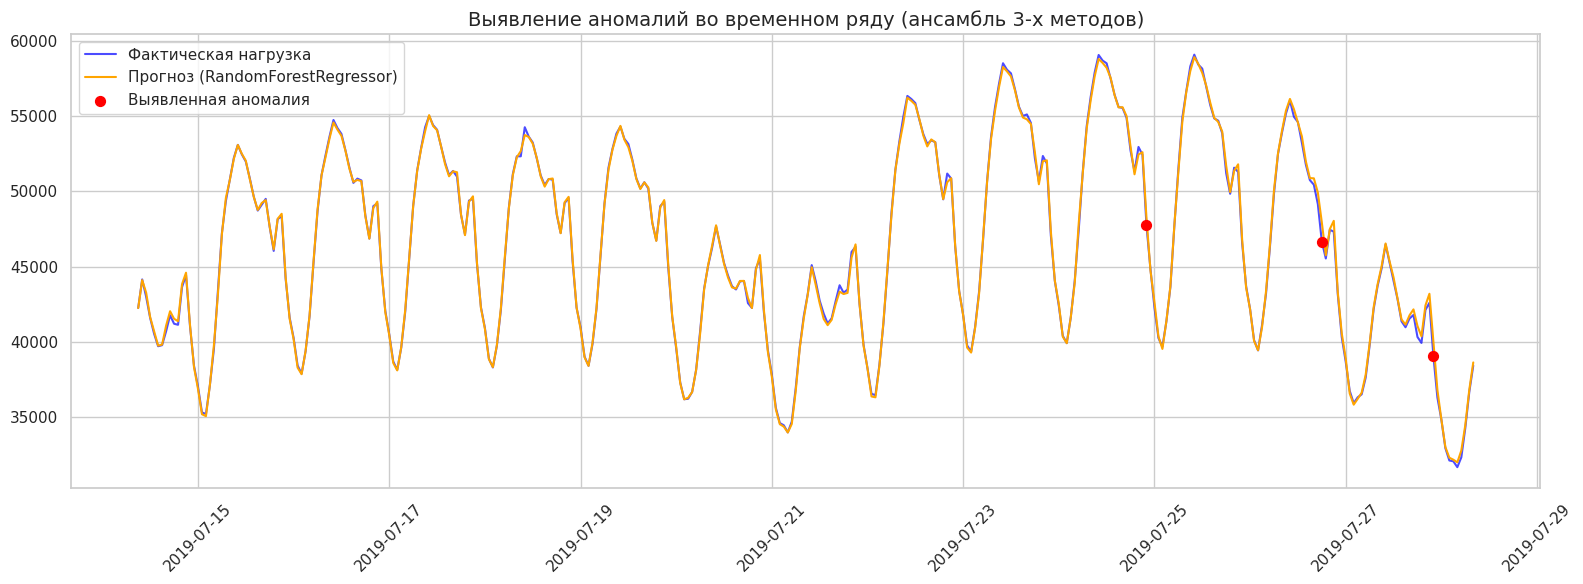

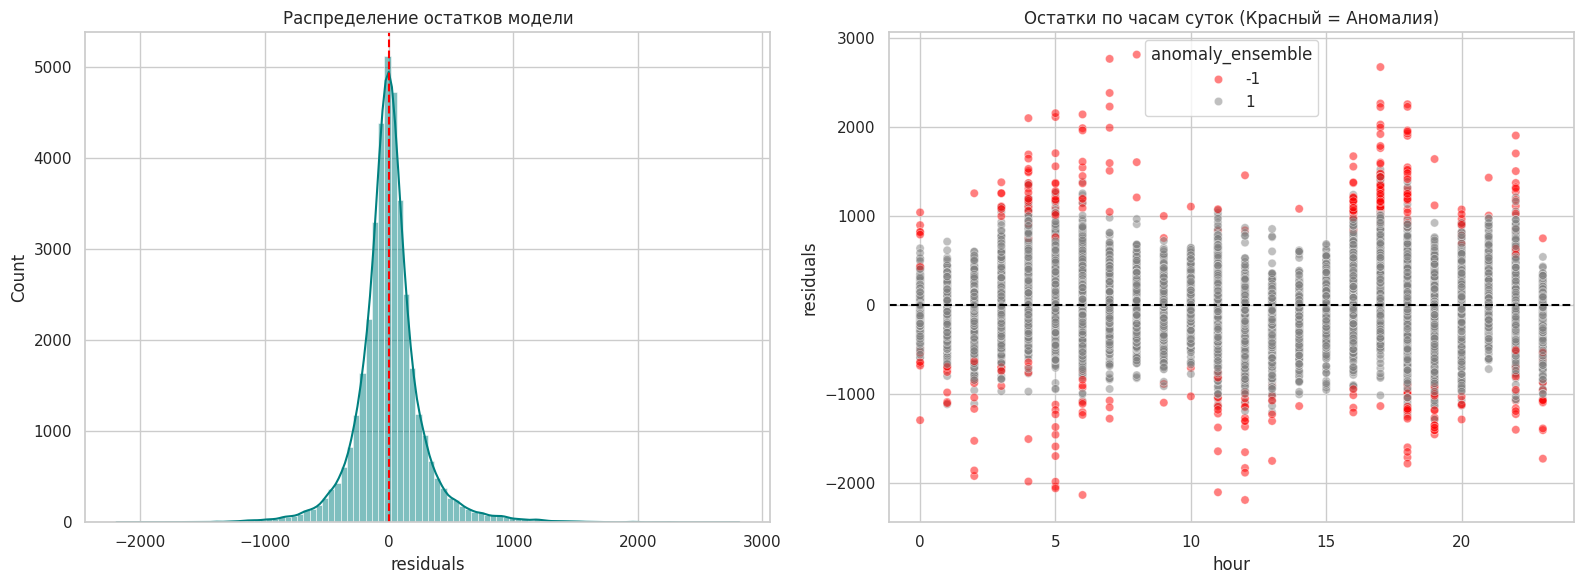


Задача №3 успешно завершена!
Результаты сохранены в папку 'task3_outputs/'


In [ ]:
print("Генерация отчетов и графиков...")

# 5.1. Сравнение ML и DL прогнозов
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test_eval['ds'], test_eval['y'], label='Факт (Test)', color='black', linewidth=2)
ax.plot(test_eval['ds'], test_eval['LGBMRegressor'], label=f'Best ML ({best_ml_model})', linestyle='--', alpha=0.8)
ax.plot(dl_preds['ds'], dl_preds['NBEATS'], label='Best DL (NBEATS)', linestyle='-.', alpha=0.8)
ax.set_title('Сравнение прогнозов: Лучшая ML vs Лучшая DL модель', fontsize=14)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{DIR_TASK3}/01_ml_vs_dl_forecast.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# 5.2. Визуализация аномалий (последние 2 недели тренировочных данных для наглядности)
plot_df = train_eval.tail(24*14).copy()
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(plot_df['ds'], plot_df['y'], label='Фактическая нагрузка', color='blue', alpha=0.7)
ax.plot(plot_df['ds'], plot_df[best_ml_model], label=f'Прогноз ({best_ml_model})', color='orange')

# Подсветка аномалий
anom_points = plot_df[plot_df['anomaly_ensemble'] == -1]
ax.scatter(anom_points['ds'], anom_points['y'], color='red', s=50, zorder=5, label='Выявленная аномалия')

ax.set_title('Выявление аномалий во временном ряду (ансамбль 3-х методов)', fontsize=14)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{DIR_TASK3}/02_anomaly_detection.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# 5.3. Распределение остатков и аномалий
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(train_eval['residuals'], bins=100, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Распределение остатков модели')
axes[0].axvline(0, color='red', linestyle='--')

sns.scatterplot(data=train_eval, x='hour', y='residuals', hue='anomaly_ensemble',
                palette={1: 'gray', -1: 'red'}, ax=axes[1], alpha=0.5)
axes[1].set_title('Остатки по часам суток (Красный = Аномалия)')
axes[1].axhline(0, color='black', linestyle='--')

plt.tight_layout()
plt.savefig(f"{DIR_TASK3}/03_residuals_and_anomalies.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nЗадача №3 успешно завершена!")
print(f"Результаты сохранены в папку '{DIR_TASK3}/'")

## Вывод

В рамках задания были реализованы методы машинного обучения, глубокого обучения и детекции аномалий для прогнозирования временного ряда потребления электроэнергии во Франции.

На этапе подготовки данных был выполнен feature engineering: сформированы календарные признаки (час, день недели, месяц, день месяца), лаговые признаки и статистики скользящего окна. Это позволило учесть сезонность и временные зависимости в данных.

Для прогнозирования были обучены модели машинного обучения: LightGBM, Random Forest и Gradient Boosting. Качество моделей оценивалось по метрикам MAE и RMSE на тестовой выборке. Среди рассмотренных ML-подходов наилучшие результаты показал Random Forest, продемонстрировав минимальные значения ошибок.

Также были исследованы модели глубокого обучения N-BEATS, N-HiTS и LSTM. Их применение позволило оценить возможности современных нейросетевых архитектур для прогнозирования временных рядов и сравнить их эффективность с классическими ML-алгоритмами.

Дополнительно была реализована система обнаружения аномалий с использованием методов Isolation Forest, Local Outlier Factor и Z-Score. Обнаруженные выбросы были визуализированы и проанализированы. Использование нескольких алгоритмов позволило повысить надёжность выявления аномальных наблюдений.

Таким образом, поставленные задачи были выполнены: проведён feature engineering, обучены и сравнены модели машинного и глубокого обучения, реализована детекция аномалий. Полученные результаты подтверждают возможность эффективного прогнозирования временного ряда нагрузки энергосистемы и выявления нетипичных значений в данных.
